**Declaring file locations**

In [ ]:
import pandas as pd
from pathlib import Path

# ===== Defining the data directories ====#
PROJECT_ROOT = Path().absolute().parent.parent
DATA_DIR = PROJECT_ROOT / "datasets" 
CLEANED_INGESTED_DATA_DIR = DATA_DIR / "cleaned_ingested_data"
cleaned_ingested_data_file = CLEANED_INGESTED_DATA_DIR / "cleaned_ingested_data.csv"




In [16]:
import pandas as pd
data = pd.read_csv(cleaned_ingested_data_file)
data.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HC,AC,HY,AY,HR,AR,season_id,Month,Year,Day
0,2025-08-15,Liverpool,Bournemouth,4,2,H,1,0,H,A Taylor,...,6,7,1,2,0,0,2025-2026,August,2025,Friday
1,2025-08-16,Aston Villa,Newcastle,0,0,D,0,0,D,C Pawson,...,3,6,1,1,1,0,2025-2026,August,2025,Saturday
2,2025-08-16,Brighton,Fulham,1,1,D,0,0,D,S Barrott,...,4,3,3,3,0,0,2025-2026,August,2025,Saturday
3,2025-08-16,Sunderland,West Ham,3,0,H,0,0,D,R Jones,...,5,7,0,1,0,0,2025-2026,August,2025,Saturday
4,2025-08-16,Tottenham,Burnley,3,0,H,1,0,H,M Oliver,...,6,5,0,0,0,0,2025-2026,August,2025,Saturday


In [17]:
data.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC',
       'HY', 'AY', 'HR', 'AR', 'season_id', 'Month', 'Year', 'Day'],
      dtype='object')

In [18]:
!pip install duckdb

In [19]:
import duckdb

In [20]:
import duckdb


duckdb.register("football_data", data)
duckdb.sql("SELECT * FROM football_data USING SAMPLE 10").show()


┌────────────┬─────────────┬───────────────┬───────┬───────┬─────────┬───────┬───────┬─────────┬───────────────┬───────┬────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────────┬───────────┬───────┬──────────┐
│    Date    │  HomeTeam   │   AwayTeam    │ FTHG  │ FTAG  │   FTR   │ HTHG  │ HTAG  │   HTR   │    Referee    │  HS   │   AS   │  HST  │  AST  │  HF   │  AF   │  HC   │  AC   │  HY   │  AY   │  HR   │  AR   │ season_id │   Month   │ Year  │   Day    │
│  varchar   │   varchar   │    varchar    │ int64 │ int64 │ varchar │ int64 │ int64 │ varchar │    varchar    │ int64 │ double │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │  varchar  │  varchar  │ int64 │ varchar  │
├────────────┼─────────────┼───────────────┼───────┼───────┼─────────┼───────┼───────┼─────────┼───────────────┼───────┼────────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────────┼───────────┼───────┼

**Quick EDA Insights**
1. Insights for this season
2. Overall for the last x seasons


**Insights for the season**

1. The distribution of the full time results this season

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import duckdb

In [103]:
data = pd.read_csv(cleaned_ingested_data_file)
COLUMN_RENAMES = {
        'HS': 'HomeShots',
        'AS': 'AwayShots'}

data = data.copy()
data = data.reset_index(drop=True)



In [106]:
data.rename(columns=COLUMN_RENAMES,inplace=True)

In [107]:
data.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'Referee', 'HomeShots', 'AwayShots', 'HST', 'AST', 'HF', 'AF',
       'HC', 'AC', 'HY', 'AY', 'HR', 'AR', 'season_id', 'Month', 'Year',
       'Day'],
      dtype='object')

In [109]:
#data = pd.read_csv(cleaned_ingested_data_file)
 
duckdb.register("football_data", data)
 
CURRENT_SEASON = "2025-2026"
PALETTE = "Set2"
sns.set_theme(style="whitegrid", palette=PALETTE)

In [41]:
duckdb.sql(f"""
    SELECT
        FTR  AS result,
        COUNT(*)   AS match_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS pct
    FROM football_data
    WHERE season_id = '{CURRENT_SEASON}'
      AND FTR IN ('H', 'A', 'D')
    GROUP BY FTR
    ORDER BY match_count DESC
""").show()

┌─────────┬─────────────┬────────┐
│ result  │ match_count │  pct   │
│ varchar │    int64    │ double │
├─────────┼─────────────┼────────┤
│ H       │         123 │  42.27 │
│ A       │          92 │  31.62 │
│ D       │          76 │  26.12 │
└─────────┴─────────────┴────────┘



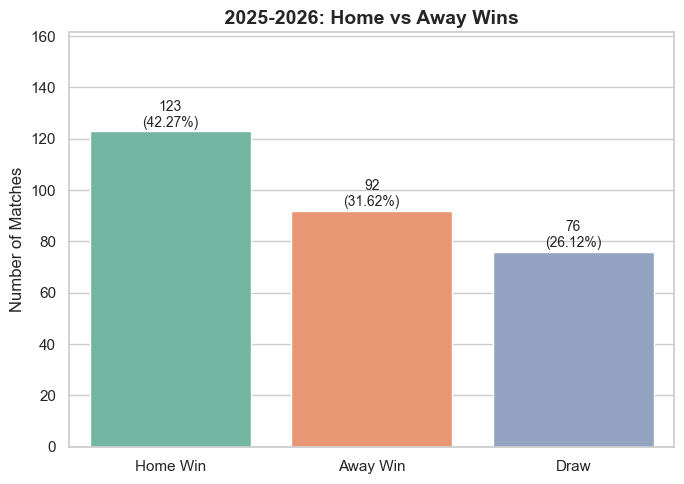

In [40]:
# Python
obs1 = (
    data[data["season_id"] == CURRENT_SEASON]["FTR"]
    .value_counts()
    .reset_index()
    .rename(columns={"FTR": "Result", "count": "Matches"})
)
obs1["Result"] = obs1["Result"].map({"H": "Home Win", "A": "Away Win", "D": "Draw"})

# Calculate percentage
total_matches = obs1["Matches"].sum()
obs1["Percentage"] = (obs1["Matches"] / total_matches * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=obs1, x="Result", y="Matches", ax=ax,palette=PALETTE,legend=False,hue="Result")
ax.set_title(f" {CURRENT_SEASON}: Home vs Away Wins ", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of Matches")

# Increase y-axis height to accommodate labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.25)

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{int(bar.get_height())}\n({obs1.iloc[i]['Percentage']}%)",
        ha="center", va="bottom", fontsize=10
    )
plt.tight_layout()
plt.savefig("obs1_home_away_wins.png", dpi=150)
plt.show()

2. This season ranks 10th in Average Goals Scored per Game

In [46]:
duckdb.sql("""
    SELECT
        season_id,
        SUM(FTHG + FTAG)                            AS total_goals,
        ROUND(AVG(FTHG + FTAG), 2)                  AS avg_goals_per_game,
        RANK() OVER (ORDER BY AVG(FTHG + FTAG) DESC) AS avg_goals_rank
    FROM football_data
    GROUP BY season_id
    ORDER BY avg_goals_per_game DESC
""").show()

┌───────────┬─────────────┬────────────────────┬────────────────┐
│ season_id │ total_goals │ avg_goals_per_game │ avg_goals_rank │
│  varchar  │   int128    │       double       │     int64      │
├───────────┼─────────────┼────────────────────┼────────────────┤
│ 2023-2024 │        1246 │               3.28 │              1 │
│ 2024-2025 │        1115 │               2.93 │              2 │
│ 2022-2023 │        1084 │               2.85 │              3 │
│ 2018-2019 │        1072 │               2.82 │              4 │
│ 2021-2022 │        1071 │               2.82 │              5 │
│ 2011-2012 │        1066 │               2.81 │              6 │
│ 2016-2017 │        1064 │                2.8 │              7 │
│ 2012-2013 │        1063 │                2.8 │              8 │
│ 2010-2011 │        1063 │                2.8 │              8 │
│ 2025-2026 │         807 │               2.77 │             10 │
│ 2009-2010 │        1053 │               2.77 │             11 │
│ 2013-201

C:\Users\juliu\AppData\Local\Temp\ipykernel_16976\3110750834.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["FTHG"] + x["FTAG"]).mean())
C:\Users\juliu\AppData\Local\Temp\ipykernel_16976\3110750834.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


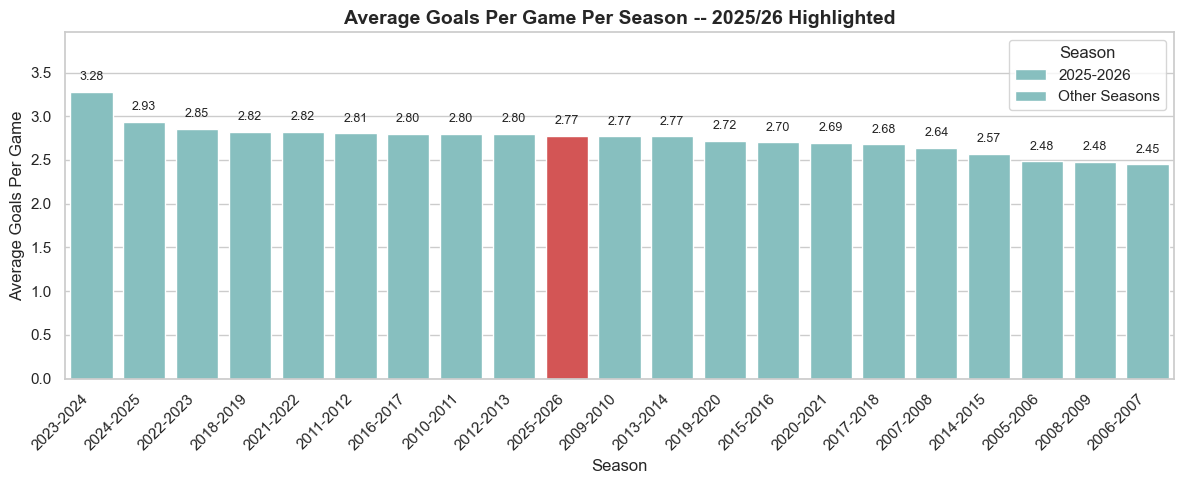

In [78]:
# Python
obs2 = (
    data.groupby("season_id")
    .apply(lambda x: (x["FTHG"] + x["FTAG"]).mean())
    .reset_index()
    .rename(columns={0: "avg_goals_per_game"})
    .sort_values("avg_goals_per_game", ascending=False)
)
obs2["highlight"] = obs2["season_id"] == CURRENT_SEASON

fig, ax = plt.subplots(figsize=(12, 5))
bars = sns.barplot(
    data=obs2, x="season_id", y="avg_goals_per_game", ax=ax,
    palette=["#E84040" if h else "#7EC8C8" for h in obs2["highlight"]]
)
ax.set_title("Average Goals Per Game Per Season -- 2025/26 Highlighted", fontsize=14, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Average Goals Per Game")

# Increase y-axis height to accommodate labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Add average labels on each bar
for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{obs2.iloc[i]['avg_goals_per_game']:.2f}",
        ha="center", va="bottom", fontsize=9
    )

# Add legend
handles = [bars.patches[obs2[obs2["highlight"]].index[0]], bars.patches[obs2[~obs2["highlight"]].index[0]]]
ax.legend(handles, ["2025-2026", "Other Seasons"], title="Season", loc="upper right")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("obs2_goals_per_season.png", dpi=150)
plt.show()

3. The season is not over yet, and we have the 3rd highest average cards per game!

In [85]:
duckdb.sql("""
    SELECT
        season_id,
        SUM(HY + AY)                                AS total_yellows,
        SUM(HR + AR)                                AS total_reds,
        SUM(HY + AY + HR + AR)                      AS total_cards_received,
        ROUND(AVG(HY + AY + HR + AR),2)                      AS avg_card_per_game,
        RANK() OVER (ORDER BY AVG(HY + AY + HR + AR) DESC) AS avg_card_per_game_rank
    FROM football_data
    GROUP BY season_id
    ORDER BY avg_card_per_game_rank
""").show()


┌───────────┬───────────────┬────────────┬──────────────────────┬───────────────────┬────────────────────────┐
│ season_id │ total_yellows │ total_reds │ total_cards_received │ avg_card_per_game │ avg_card_per_game_rank │
│  varchar  │    int128     │   int128   │        int128        │      double       │         int64          │
├───────────┼───────────────┼────────────┼──────────────────────┼───────────────────┼────────────────────────┤
│ 2023-2024 │          1586 │         57 │                 1643 │              4.32 │                      1 │
│ 2024-2025 │          1539 │         52 │                 1591 │              4.19 │                      2 │
│ 2025-2026 │          1090 │         31 │                 1121 │              3.85 │                      3 │
│ 2014-2015 │          1364 │         71 │                 1435 │              3.78 │                      4 │
│ 2016-2017 │          1380 │         41 │                 1421 │              3.74 │                      5 │
│

C:\Users\juliu\AppData\Local\Temp\ipykernel_16976\2377925299.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=obs3, x="season_id", y="avg_cards_per_game", ax=ax,


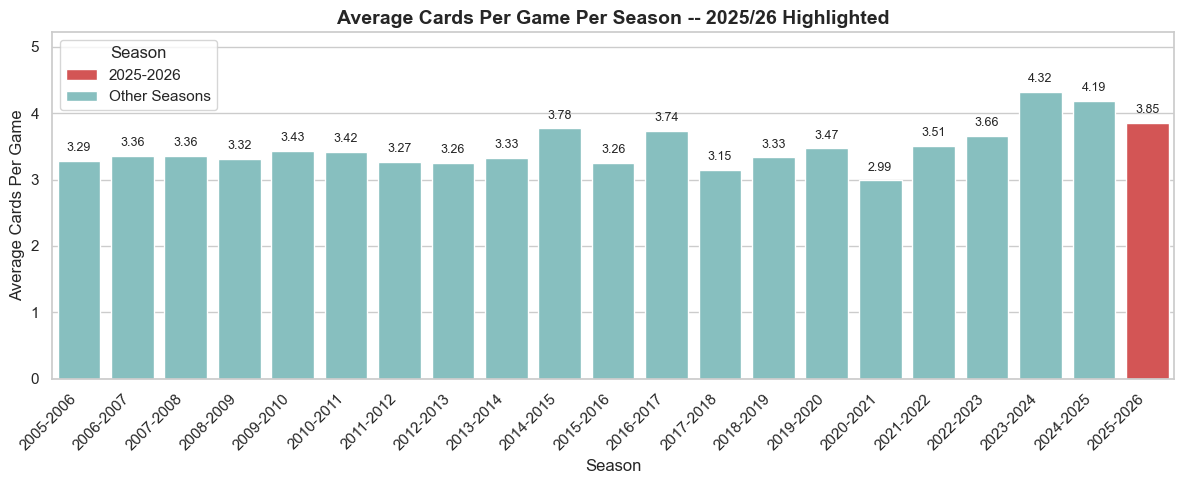

In [120]:
obs3 = data.groupby("season_id").agg(
    avg_cards_per_game=("HY", lambda x: ((x + data.loc[x.index, "AY"]) + (data.loc[x.index, "HR"] + data.loc[x.index, "AR"])).mean()),
).reset_index()

obs3["highlight"] = obs3["season_id"] == CURRENT_SEASON

fig, ax = plt.subplots(figsize=(12, 5))
bars = sns.barplot(data=obs3, x="season_id", y="avg_cards_per_game", ax=ax,
            palette=["#E84040" if h else "#7EC8C8" for h in obs3["highlight"]])
ax.set_title("Average Cards Per Game Per Season -- 2025/26 Highlighted", fontsize=14, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Average Cards Per Game")

# Increase y-axis height to accommodate labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Add average labels on each bar
for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{obs3.iloc[i]['avg_cards_per_game']:.2f}",
        ha="center", va="bottom", fontsize=9
    )

# Add legend
handles = [bars.patches[obs3[obs3["highlight"]].index[0]], bars.patches[obs3[~obs3["highlight"]].index[0]]]
ax.legend(handles, ["2025-2026", "Other Seasons"], title="Season", loc="upper left")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("obs3_cards_per_season.png", dpi=150)
plt.show()

In [110]:



duckdb.sql(f"""
    WITH team_shots AS (
        SELECT HomeTeam AS team, SUM(HomeShots) AS shots, SUM(FTHG) AS goals
        FROM football_data WHERE season_id = '{CURRENT_SEASON}' GROUP BY HomeTeam
        UNION ALL
        SELECT AwayTeam, SUM(AwayShots), SUM(FTAG)
        FROM football_data WHERE season_id = '{CURRENT_SEASON}' GROUP BY AwayTeam
    )
    SELECT
        team,
        SUM(shots)                                          AS total_shots,
        SUM(goals)                                          AS total_goals,
        ROUND(SUM(goals) * 100.0 / NULLIF(SUM(shots), 0), 2) AS conversion_rate_pct
    FROM team_shots
    GROUP BY team
    ORDER BY conversion_rate_pct ASC
    LIMIT 10
""").show()


┌────────────────┬─────────────┬─────────────┬─────────────────────┐
│      team      │ total_shots │ total_goals │ conversion_rate_pct │
│    varchar     │   double    │   int128    │       double        │
├────────────────┼─────────────┼─────────────┼─────────────────────┤
│ Nott'm Forest  │       373.0 │          28 │                7.51 │
│ Wolves         │       273.0 │          22 │                8.06 │
│ Crystal Palace │       338.0 │          33 │                9.76 │
│ Leeds          │       363.0 │          37 │               10.19 │
│ Brighton       │       370.0 │          38 │               10.27 │
│ Liverpool      │       457.0 │          48 │                10.5 │
│ Everton        │       321.0 │          34 │               10.59 │
│ Aston Villa    │       365.0 │          39 │               10.68 │
│ Newcastle      │       386.0 │          42 │               10.88 │
│ Sunderland     │       275.0 │          30 │               10.91 │
└────────────────┴─────────────┴──

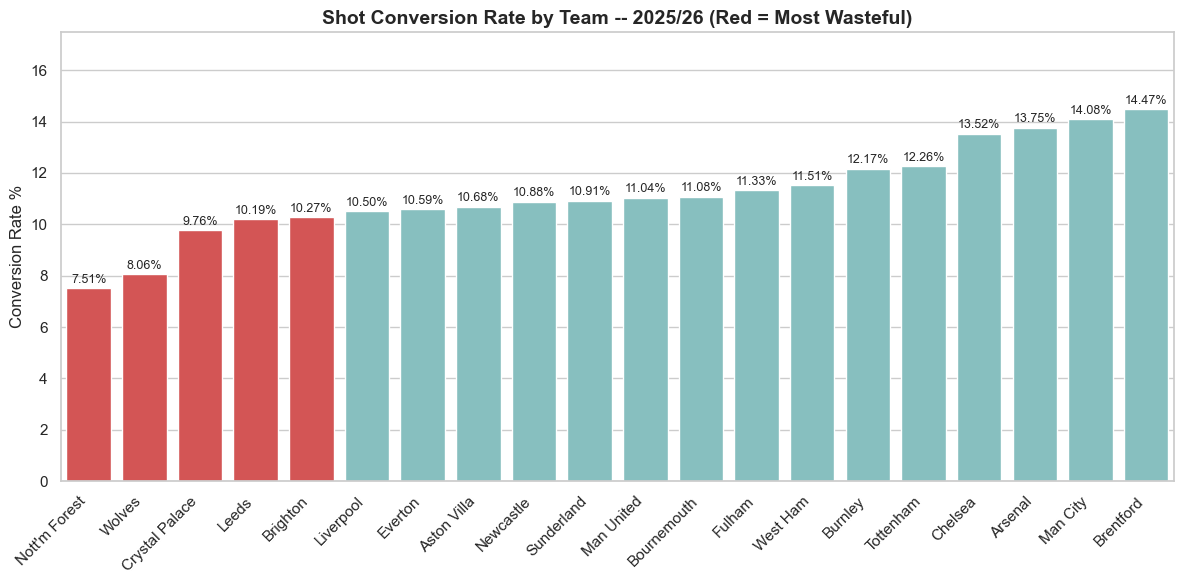

In [ ]:
home_shots = data[data["season_id"] == CURRENT_SEASON].groupby("HomeTeam").agg(
    shots=("HomeShots", "sum"), goals=("FTHG", "sum")
).reset_index().rename(columns={"HomeTeam": "team"})
 
away_shots = data[data["season_id"] == CURRENT_SEASON].groupby("AwayTeam").agg(
    shots=("AwayShots", "sum"), goals=("FTAG", "sum")
).reset_index().rename(columns={"AwayTeam": "team"})
 
obs4 = (
    pd.concat([home_shots, away_shots])
    .groupby("team")
    .sum()
    .reset_index()
)
obs4["conversion_rate"] = round(obs4["goals"] / obs4["shots"] * 100, 2)
obs4 = obs4.sort_values("conversion_rate")
 
fig, ax = plt.subplots(figsize=(12, 6))
colors_list = ["#E84040" if i < 5 else "#7EC8C8" for i in range(len(obs4))]
sns.barplot(data=obs9, x="team", y="conversion_rate", ax=ax, palette=colors_list, legend=False,hue=x)
ax.set_title("Shot Conversion Rate by Team -- 2025/26 (Red = Most Wasteful)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Conversion Rate %")

# Increase y-axis height to accommodate labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Add conversion rate labels on each bar
for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{obs4.iloc[i]['conversion_rate']:.2f}%",
        ha="center", va="bottom", fontsize=9
    )

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("obs4_shot_conversion.png", dpi=150)
plt.show()

In [ ]:
duckdb.sql(f"""
    WITH home_results AS (
        SELECT
            season_id,
            HomeTeam AS team,
            Date,
            CASE WHEN FTR IN ('H', 'D') THEN 1 ELSE 0 END  AS unbeaten
        FROM football_data
        ORDER BY HomeTeam, Date
    ),
    streaks AS (
        SELECT
            season_id,
            team,
            SUM(unbeaten) OVER (
                PARTITION BY season_id, team
                ORDER BY Date
                ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
            ) AS running_unbeaten
        FROM home_results
    )
    SELECT
        season_id,
        team,
        MAX(running_unbeaten) AS longest_unbeaten_home_run
    FROM streaks
    GROUP BY season_id, team
    HAVING season_id = '{CURRENT_SEASON}'
    ORDER BY longest_unbeaten_home_run DESC
    LIMIT 10
""").show()

┌───────────┬─────────────┬───────────────────────────┐
│ season_id │    team     │ longest_unbeaten_home_run │
│  varchar  │   varchar   │          int128           │
├───────────┼─────────────┼───────────────────────────┤
│ 2025-2026 │ Man City    │                        14 │
│ 2025-2026 │ Bournemouth │                        13 │
│ 2025-2026 │ Arsenal     │                        13 │
│ 2025-2026 │ Man United  │                        12 │
│ 2025-2026 │ Sunderland  │                        12 │
│ 2025-2026 │ Brighton    │                        12 │
│ 2025-2026 │ Brentford   │                        11 │
│ 2025-2026 │ Liverpool   │                        11 │
│ 2025-2026 │ Aston Villa │                        11 │
│ 2025-2026 │ Chelsea     │                        11 │
└───────────┴─────────────┴───────────────────────────┘
  10 rows                                   3 columns



C:\Users\juliu\AppData\Local\Temp\ipykernel_16976\1669431849.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=obs5, x="team", y="longest_streak", ax=ax, palette=PALETTE)


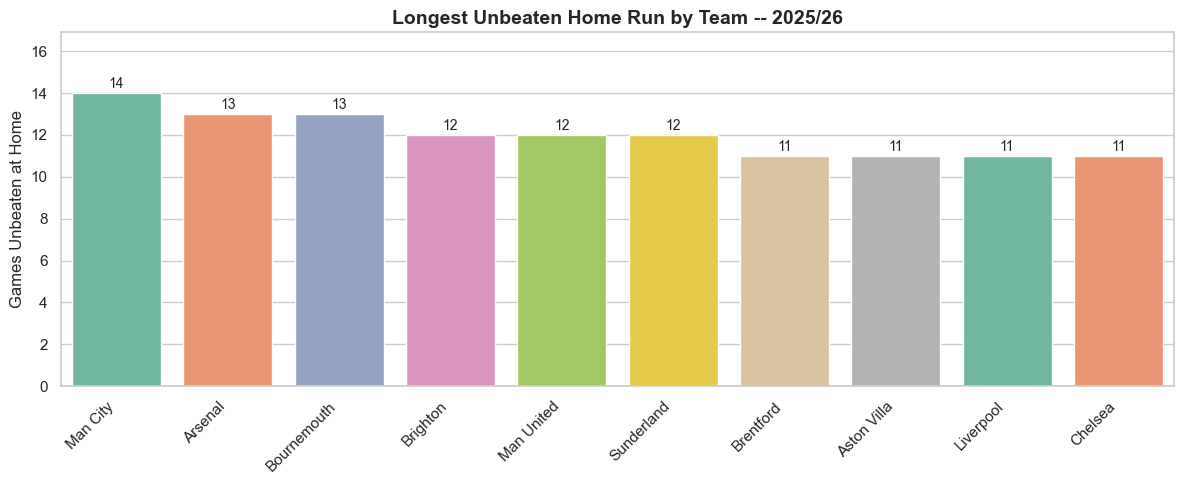

In [ ]:
current_data = data[data["season_id"] == CURRENT_SEASON].copy()
current_data = current_data.sort_values(["HomeTeam", "Date"])
current_data["unbeaten_home"] = current_data["FTR"].isin(["H", "D"]).astype(int)
 
def max_running_unbeaten(series):
    running = 0
    max_running = 0
    for val in series:
        running += val
        max_running = max(max_running, running)
    return max_running
 
obs5 = (
    current_data.groupby("HomeTeam")["unbeaten_home"]
    .apply(max_running_unbeaten)
    .reset_index()
    .rename(columns={"HomeTeam": "team", "unbeaten_home": "longest_streak"})
    .sort_values("longest_streak", ascending=False)
    .head(10)
)
 
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=obs5, x="team", y="longest_streak", ax=ax, palette=PALETTE)
ax.set_title("Longest Unbeaten Home Run by Team -- 2025/26", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Games Unbeaten at Home")

# Increase y-axis height to accommodate labels
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

for i, bar in enumerate(ax.patches):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        int(obs5.iloc[i]["longest_streak"]),
        ha="center", va="bottom", fontsize=10
    )

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("obs4_unbeaten_home_run.png", dpi=150)
plt.show()

In [ ]:
duckdb.sql("""
    SELECT
        season_id,
        ROUND(AVG(HTHG + HTAG), 3)                          AS avg_first_half_goals,
        ROUND(AVG((FTHG - HTHG) + (FTAG - HTAG)), 3)        AS avg_second_half_goals,
        ROUND(AVG(FTHG + FTAG), 3)                          AS avg_total_goals
    FROM football_data
    GROUP BY season_id
    ORDER BY season_id
""").show()

┌───────────┬──────────────────────┬───────────────────────┬─────────────────┐
│ season_id │ avg_first_half_goals │ avg_second_half_goals │ avg_total_goals │
│  varchar  │        double        │        double         │     double      │
├───────────┼──────────────────────┼───────────────────────┼─────────────────┤
│ 2005-2006 │                1.163 │                 1.321 │           2.484 │
│ 2006-2007 │                1.105 │                 1.345 │            2.45 │
│ 2007-2008 │                1.092 │                 1.545 │           2.637 │
│ 2008-2009 │                1.047 │                 1.432 │           2.479 │
│ 2009-2010 │                1.216 │                 1.555 │           2.771 │
│ 2010-2011 │                1.253 │                 1.545 │           2.797 │
│ 2011-2012 │                1.221 │                 1.584 │           2.805 │
│ 2012-2013 │                1.221 │                 1.576 │           2.797 │
│ 2013-2014 │                1.218 │                

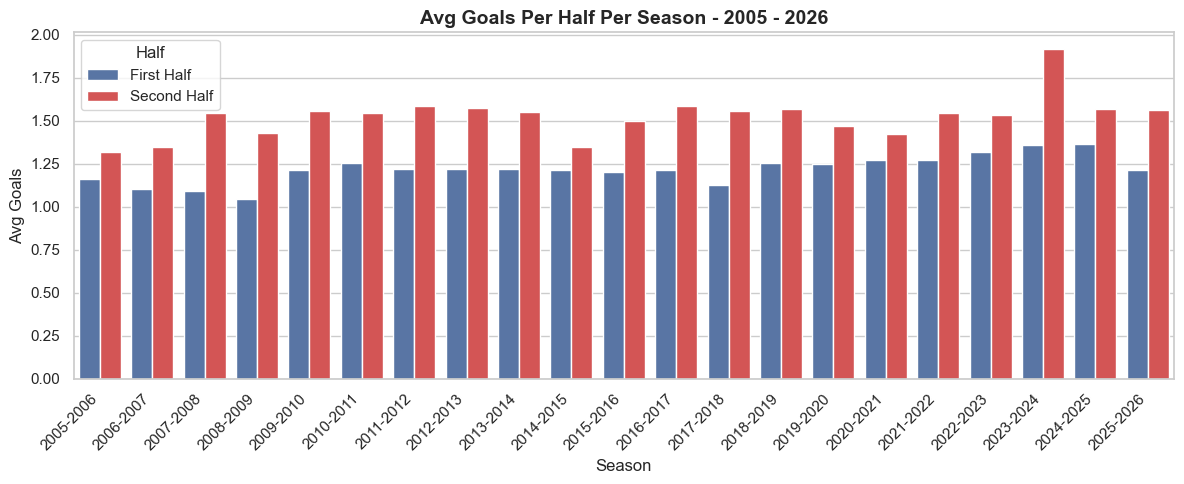

In [155]:
data["first_half_goals"] = data["HTHG"] + data["HTAG"]
data["second_half_goals"] = (data["FTHG"] - data["HTHG"]) + (data["FTAG"] - data["HTAG"])
 
obs6 = (
    data.groupby("season_id")
    .agg(
        avg_first_half=("first_half_goals", "mean"),
        avg_second_half=("second_half_goals", "mean")
    )
    .reset_index()
)
obs6_melted = obs6.melt(id_vars="season_id", var_name="Half", value_name="Avg Goals")
obs6_melted["Half"] = obs6_melted["Half"].map({
    "avg_first_half": "First Half",
    "avg_second_half": "Second Half"
})
 
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=obs6_melted, x="season_id", y="Avg Goals", hue="Half",
            palette={"First Half": "#4C72B0", "Second Half": "#E84040"}, ax=ax)
ax.set_title("Avg Goals Per Half Per Season - 2005 - 2026", fontsize=14, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Avg Goals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("obs6_half_time_goals.png", dpi=150)
plt.show()